<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt



In [7]:
df = pd.read_csv("smurph61_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,lyc102_ifem,000349ee3bbfe4b011a29a30f6d47a7a9486f5f6,GitHub Actions <actions@github.com>,1616069558,Built site for parameters: 0.12.0.1@14c1600\n,2021-03
1,lyc102_ifem,00059db8ebf302fd696ae8a99df3b39ac57ea737,Daniel <mail@danielluedecke.de>,1603799266,save object name\n,2020-10
2,lyc102_ifem,00084e7cfa0e749b92cca233453e6c5483ac5097,Daniel <mail@danielluedecke.de>,1600375007,fix check issues\n,2020-09
3,lyc102_ifem,000b5bf7ed9e371fedc9625f78dd828d01f615d7,Daniel <mail@danielluedecke.de>,1659254294,lint\n,2022-07
4,lyc102_ifem,000f09d743ee4463cca9506d99a7fe48c12737ba,Dominique Makowski <dom.mak19@gmail.com>,1620566023,minor\n,2021-05


In [8]:
prj='mmorise_world'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


ValueError: Neither `start` nor `end` can be NaT

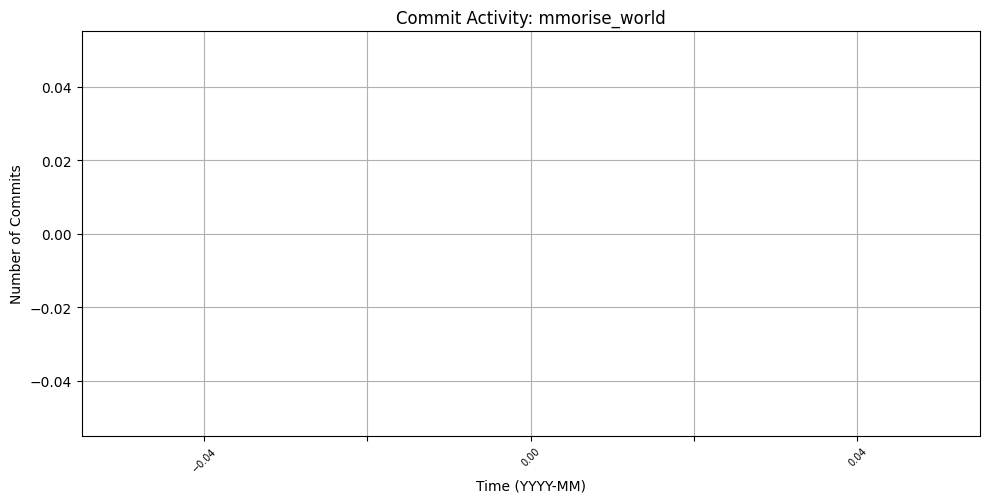

In [5]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("your-net-id-here_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv